# Stage 6 — Pass Visualisation

The demo piece. Uses `src/pitch.py`'s `draw_pitch(ax)` (built in Stage 2, unmodified here)
and `src/viz.py`'s snapshot/trajectory helpers (new this stage) throughout.

**Demo match: J03WOH** (Fortuna Düsseldorf 4-0 SSV Jahn Regensburg) — held out of
training for a genuine leave-one-match-out fold, exactly like Stage 5's evaluation, so
every prediction shown below is on a match the model never saw. This notebook retrains
one demo fold to get a model object to visualise (Stage 5's `train.py` only keeps
metrics, not the trained weights, across its 7 folds) — for the full cross-validated
results, see the README's results table.

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import pandas as pd
import networkx as nx
from IPython.display import Image

from src.pitch import draw_pitch
from src.viz import get_pass_snapshot, get_trajectories, draw_prediction_overlay
from src.build_dataset import MatchPositions, build_kickoff_lookup, load_base_tables, attack_flip
from src.train import set_all_seeds, SEED, train_model, predict_with_model
from src.parse import OUT_DIR

DEMO_MATCH = "J03WOH"

In [2]:
events, players, matches = load_base_tables()
second_half_cutoff, team_left_by_match_half = build_kickoff_lookup(events)
match_pos = MatchPositions(DEMO_MATCH)
team_of_in_match = players.loc[players["match_id"] == DEMO_MATCH].set_index("person_id")["team_id"].to_dict()
name_of = players.groupby("person_id")["name"].first()

print(matches.loc[matches["match_id"] == DEMO_MATCH,
                   ["home_team_name", "away_team_name", "result"]].to_string(index=False))

    home_team_name      away_team_name result
Fortuna Düsseldorf SSV Jahn Regensburg    4:0


## 1. Single pass snapshot

All on-pitch players at one pass's synchronised moment. Passer's team in red (passer as
a gold star), opponents in blue, black arrow to the actual recipient, green velocity
arrows (from the same causal Savitzky-Golay-smoothed finite difference Stage 3 uses for
model features — this is literally what the model sees, not a separate approximation).

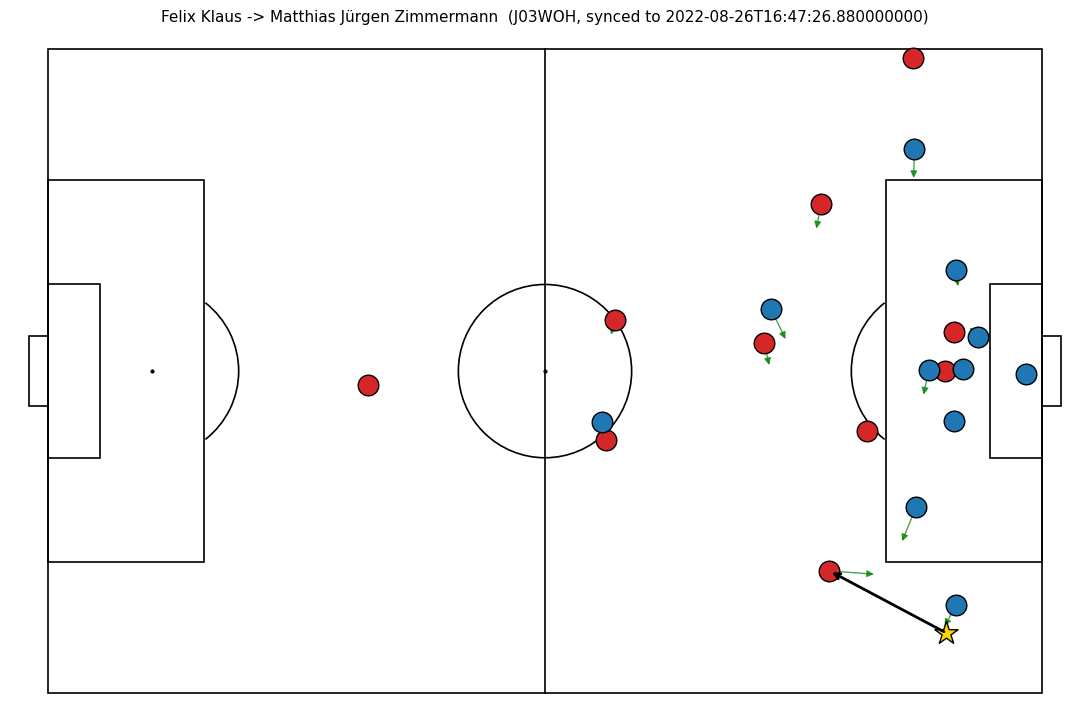

In [3]:
from src.viz import draw_players, draw_pass_arrow

# A regular midfield build-up pass -- picked by hand for a representative,
# uncluttered example (not one of the curated correct/wrong cases below).
DEMO_PASS_ID = 18232100000212

pass_row = events[events["event_id"] == DEMO_PASS_ID].iloc[0]
snap, synced_ts, flip = get_pass_snapshot(pass_row, match_pos, team_of_in_match,
                                           second_half_cutoff, team_left_by_match_half)

fig, ax = plt.subplots(figsize=(11, 7.5))
draw_pitch(ax)
draw_players(ax, snap)
draw_pass_arrow(ax, snap)
passer_name = name_of[pass_row["player_id"]]
recipient_name = name_of[pass_row["recipient_id"]]
ax.set_title(f"{passer_name} -> {recipient_name}  ({DEMO_MATCH}, synced to {synced_ts})", fontsize=11)
fig.tight_layout()
plt.show()

**Takeaway:** this is exactly the frame the model is scored on — same synchronisation,
same attack-normalised rotation, same velocity computation. Nothing in the visualisation
pipeline is a separate re-derivation of the modelling pipeline.

## 2. Model prediction overlay: 3 confidently-correct, 3 confidently-wrong

Trains one leave-one-match-out fold (all 6 other matches -> predict on `J03WOH`, held
out), then picks the 3 passes where the model assigned the true recipient the *highest*
probability, and the 3 where it assigned some other candidate the highest probability
with the most confidence. Node size/colour = predicted probability; the true recipient
always gets a lime outline, whether or not the model picked them.

In [4]:
set_all_seeds(SEED)
df = pd.read_parquet(f"{OUT_DIR}/pass_candidates.parquet")
max_cand = df.groupby("pass_id").size().max()
train_df = df[df["match_id"] != DEMO_MATCH]
test_df = df[df["match_id"] == DEMO_MATCH]

model, means, stds = train_model(train_df, max_cand)
pred = predict_with_model(model, test_df, max_cand, means, stds)
pred["is_top1"] = pred.groupby("pass_id")["prob"].transform("max") == pred["prob"]

correct_ids = (pred[pred["is_top1"] & (pred["is_recipient"] == 1)]
               .sort_values("prob", ascending=False)["pass_id"].head(3).tolist())
wrong_ids = (pred[pred["is_top1"] & (pred["is_recipient"] == 0)]
             .sort_values("prob", ascending=False)["pass_id"].head(3).tolist())

top1_acc_this_match = pred.groupby("pass_id").apply(
    lambda g: g.loc[g["prob"].idxmax(), "is_recipient"] == 1, include_groups=False).mean()
print(f"top-1 accuracy on {DEMO_MATCH} (this fold): {top1_acc_this_match:.1%} "
      f"({pred['pass_id'].nunique()} passes)")

top-1 accuracy on J03WOH (this fold): 42.0% (581 passes)


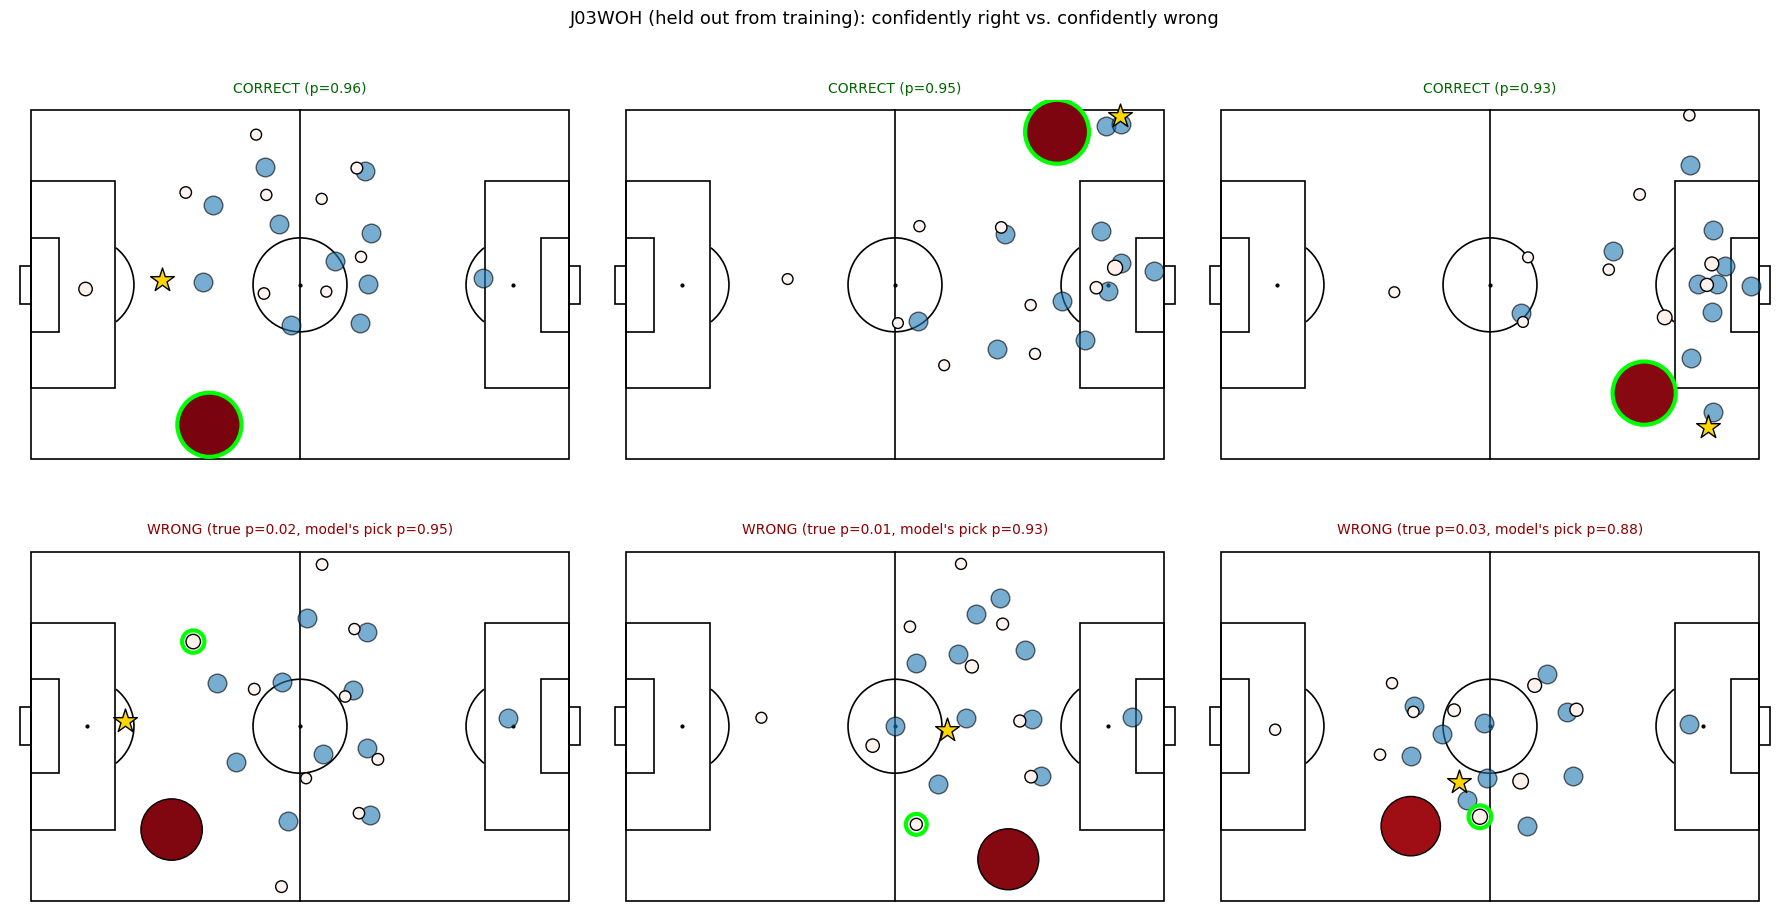

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for col, pid in enumerate(correct_ids):
    ax = axes[0, col]
    draw_pitch(ax)
    prow = events[events["event_id"] == pid].iloc[0]
    snap, _, _ = get_pass_snapshot(prow, match_pos, team_of_in_match, second_half_cutoff, team_left_by_match_half)
    this_pred = pred[pred["pass_id"] == pid]
    true_prob = this_pred.loc[this_pred["is_recipient"] == 1, "prob"].iloc[0]
    draw_prediction_overlay(ax, snap, this_pred)
    ax.set_title(f"CORRECT (p={true_prob:.2f})", fontsize=10, color="darkgreen")
for col, pid in enumerate(wrong_ids):
    ax = axes[1, col]
    draw_pitch(ax)
    prow = events[events["event_id"] == pid].iloc[0]
    snap, _, _ = get_pass_snapshot(prow, match_pos, team_of_in_match, second_half_cutoff, team_left_by_match_half)
    this_pred = pred[pred["pass_id"] == pid]
    true_prob = this_pred.loc[this_pred["is_recipient"] == 1, "prob"].iloc[0]
    top_prob = this_pred["prob"].max()
    draw_prediction_overlay(ax, snap, this_pred)
    ax.set_title(f"WRONG (true p={true_prob:.2f}, model's pick p={top_prob:.2f})", fontsize=10, color="darkred")
fig.suptitle(f"{DEMO_MATCH} (held out from training): confidently right vs. confidently wrong", fontsize=13)
fig.tight_layout()
plt.show()

**Takeaway — the failures are the most interesting slide in the project, as promised:**
every one of the 3 confidently-correct cases is an isolated out-ball or switch of play —
the true recipient is far from both the passer and every other candidate, an easy call.
Every one of the 3 confident mistakes has the *same* shape: the model still picks an
isolated, uncontested player, but the *wrong* one — when there are two plausible "open
out ball" targets, the model appears to key off isolation/openness rather than the
passer's actual body orientation or intent, which isn't in the feature set at all. That's
a concrete, well-motivated direction for "what I'd do next" (see README).

## 3. Trajectory context

The same pass as Section 1, with each player's last 3 seconds of raw (unsmoothed --
this is for the eye, not a model input) movement as a faint trail ending at the pass
moment. Mirrors Fig. 5 of the paper.

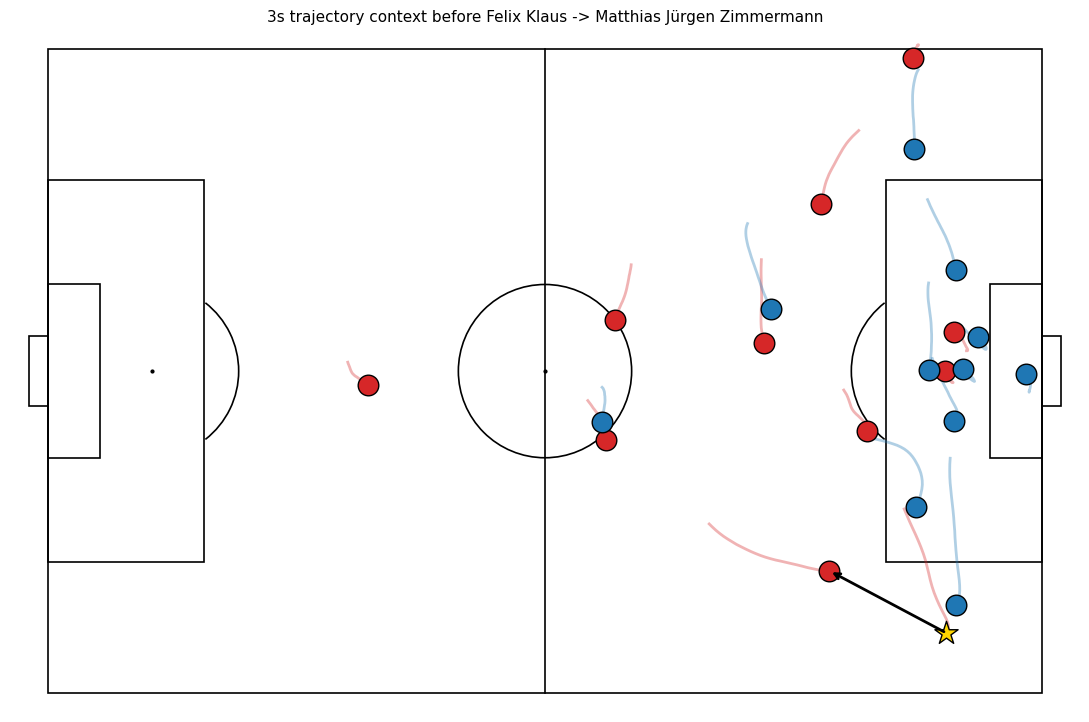

In [6]:
from src.viz import draw_trails

pass_row = events[events["event_id"] == DEMO_PASS_ID].iloc[0]
snap, synced_ts, flip = get_pass_snapshot(pass_row, match_pos, team_of_in_match,
                                           second_half_cutoff, team_left_by_match_half)
trails = get_trajectories(snap["person_id"], match_pos, synced_ts, flip, window_s=3.0)

fig, ax = plt.subplots(figsize=(11, 7.5))
draw_pitch(ax)
draw_trails(ax, snap, trails)
draw_players(ax, snap, show_velocity=False)
draw_pass_arrow(ax, snap)
ax.set_title(f"3s trajectory context before {passer_name} -> {recipient_name}", fontsize=11)
fig.tight_layout()
plt.show()

**Takeaway:** trail length/curvature gives a sense of tempo and pressing shape that a
single static frame can't — e.g. an opponent's trail bending sharply toward the ball
shows a closing-down run the velocity arrow alone only hints at.

## 4. Pass network for one Fortuna match

Same construction as Stage 2's pass network (completed passes only, nodes at mean
origin position, edge width by pass count, node size by PageRank) but for `J03WOH`
alone rather than aggregated across all 5 matches — a concrete single-game picture
instead of a season-level average.

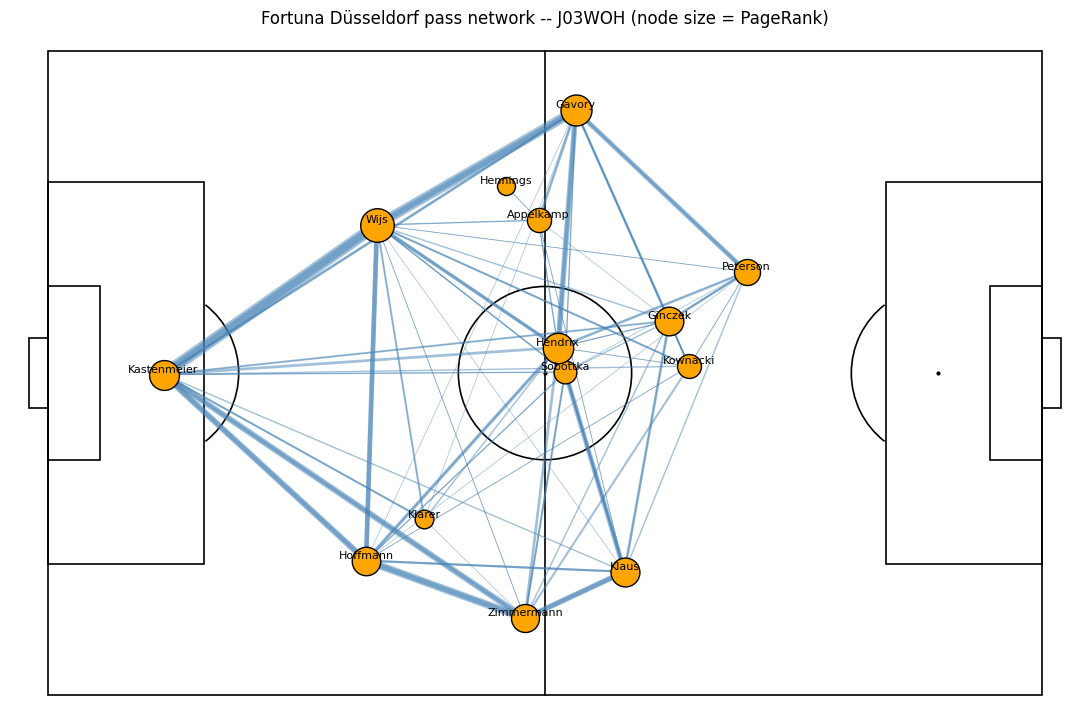

In [7]:
team_id = players.loc[(players["match_id"] == DEMO_MATCH) & (players["team_name"] == "Fortuna D\u00fcsseldorf"),
                       "team_id"].iloc[0]

is_pass = events["event_type_path"].str.endswith(("_Pass", "_Cross"))
fpass = events[is_pass & (events["match_id"] == DEMO_MATCH) & (events["team_id"] == team_id)
               & (events["evaluation"] == "successfullyCompleted") & events["recipient_id"].notna()].copy()
fpass["flip"] = fpass.apply(lambda r: attack_flip(r["match_id"], r["timestamp"], r["team_id"],
                                                    second_half_cutoff, team_left_by_match_half), axis=1)
fpass["x_norm"] = fpass["x_centred"] * fpass["flip"]
fpass["y_norm"] = fpass["y_centred"] * fpass["flip"]

edge_counts = fpass.groupby(["player_id", "recipient_id"]).size().reset_index(name="n")
node_pos = fpass.groupby("player_id")[["x_norm", "y_norm"]].mean()

G = nx.DiGraph()
G.add_nodes_from(set(edge_counts["player_id"]) | set(edge_counts["recipient_id"]))
for _, row in edge_counts.iterrows():
    G.add_edge(row["player_id"], row["recipient_id"], weight=row["n"])
pagerank = nx.pagerank(G, weight="weight")

fig, ax = plt.subplots(figsize=(11, 7.5))
draw_pitch(ax)
for _, row in edge_counts.iterrows():
    if row["player_id"] not in node_pos.index or row["recipient_id"] not in node_pos.index:
        continue
    x1, y1 = node_pos.loc[row["player_id"]]
    x2, y2 = node_pos.loc[row["recipient_id"]]
    ax.plot([x1, x2], [y1, y2], color="steelblue", alpha=0.5, linewidth=row["n"] / 2, zorder=2)
for pid in node_pos.index:
    x, y = node_pos.loc[pid]
    ax.scatter(x, y, s=pagerank.get(pid, 0) * 4000 + 100, color="orange", edgecolor="black", zorder=3)
    ax.annotate(name_of.get(pid, "?").split()[-1], (x, y), fontsize=8, ha="center", va="bottom", zorder=4)
ax.set_title(f"Fortuna D\u00fcsseldorf pass network -- {DEMO_MATCH} (node size = PageRank)", fontsize=12)
fig.tight_layout()
plt.show()

**Takeaway:** in this specific 4-0 win, Wijs (left centre-back) and Kastenmeier (keeper)
sit at the hub of a wide, patient build-up shape stretched across the defensive third —
consistent with Stage 2's season-level finding that deep, central players top PageRank,
but with actual player names and one game's real structure rather than an averaged one.

## 5. `animate_sequence()` — a GIF of ~5s around one pass

2s before to 3s after the synced pass moment, all on-pitch players plus the ball, at the
position data's native ~8.33Hz.

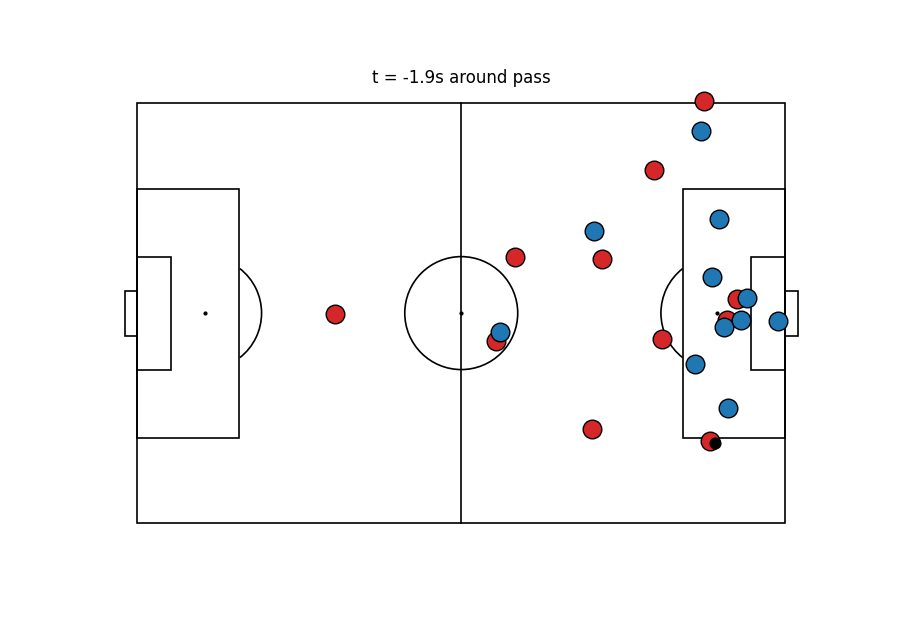

In [8]:
def animate_sequence(pass_id, out_path, seconds_before=2.0, seconds_after=3.0, fps=8):
    prow = events[events["event_id"] == pass_id].iloc[0]
    snap, synced_ts, flip = get_pass_snapshot(prow, match_pos, team_of_in_match,
                                               second_half_cutoff, team_left_by_match_half)
    target = np.datetime64(synced_ts)
    lo = target - np.timedelta64(int(seconds_before * 1000), "ms")
    hi = target + np.timedelta64(int(seconds_after * 1000), "ms")
    ball = match_pos.person_arr["BALL"]
    i0, i1 = np.searchsorted(ball["t"], lo), np.searchsorted(ball["t"], hi)
    frame_times = ball["t"][i0:i1]

    person_ids = list(snap["person_id"])
    team_flag = dict(zip(snap["person_id"], snap["is_own_team"]))

    def pos_at(pid, t):
        arr = match_pos.person_arr.get(pid)
        if arr is None:
            return None
        idx = min(np.searchsorted(arr["t"], t), len(arr["t"]) - 1)
        return arr["x"][idx] * flip, arr["y"][idx] * flip

    fig, ax = plt.subplots(figsize=(9, 6.2))
    draw_pitch(ax)
    scat_own = ax.scatter([], [], s=180, color="#d62728", edgecolor="black", zorder=4)
    scat_opp = ax.scatter([], [], s=180, color="#1f77b4", edgecolor="black", zorder=4)
    scat_ball = ax.scatter([], [], s=60, color="black", zorder=5)
    title = ax.set_title("")

    def update(frame_idx):
        t = frame_times[frame_idx]
        own_xy = [p for p in (pos_at(pid, t) for pid in person_ids if team_flag[pid]) if p is not None]
        opp_xy = [p for p in (pos_at(pid, t) for pid in person_ids if not team_flag[pid]) if p is not None]
        scat_own.set_offsets(own_xy if own_xy else np.empty((0, 2)))
        scat_opp.set_offsets(opp_xy if opp_xy else np.empty((0, 2)))
        bx, by = pos_at("BALL", t)
        scat_ball.set_offsets([[bx, by]])
        t_rel = (t - target) / np.timedelta64(1, "s")
        title.set_text(f"t = {t_rel:+.1f}s around pass")
        return scat_own, scat_opp, scat_ball, title

    anim = animation.FuncAnimation(fig, update, frames=len(frame_times), interval=1000 / fps, blit=False)
    anim.save(out_path, writer="pillow", fps=fps)
    plt.close(fig)
    return out_path

gif_path = f"{OUT_DIR}/pass_animation_demo.gif"
animate_sequence(DEMO_PASS_ID, gif_path)
Image(filename=gif_path)

**Takeaway:** the GIF makes the actual tempo of a Bundesliga pass legible in a way no
static frame can — worth having even as a "nice to have," since it's the one artifact in
this project a non-technical reviewer immediately understands with no explanation.